In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import seaborn as sns

# Mathematical Analysis of Thermal Performance in Ventilated Facades

## 1. Introduction
In modern construction, ventilated facades are essential for energy efficiency and structural longevity. However, the continuity of insulation is often interrupted by structural components like aluminum brackets and anchors. These intersections create "thermal bridges."

## 2. Problem Formulation
The goal of this project is to mathematically model the heat transfer through a multi-layered ventilated facade. We will:
* Calculate the total thermal resistance ($R_{total}$) of a wall assembly.
* Determine the overall Heat Transfer Coefficient ($U$-value).
* Analyze the impact of point thermal bridges using mathematical approximations.

## 3. Mathematical Background

### 3.1. Heat Transfer Physics
To analyze the U-value, we rely on Fourier's Law of Heat Conduction. In a one-dimensional steady state, the rate of heat transfer is defined by the derivative of temperature ($T$) with respect to distance ($x$):
$$q = -k \frac{dT}{dx}$$
This derivative represents the temperature gradient across the facade layers.

### 3.2. Modelling Multi-layered Assemblies
We treat the facade as a system of thermal resistances. For a wall with $n$ layers, the total thermal resistance ($R_{tot}$) is calculated as:
$$R_{tot} = R_{si} + \sum_{i=1}^{n} \frac{d_i}{\lambda_i} + R_{se}$$
Where:
* $d_i$ is the thickness of layer $i$.
* $\lambda_i$ is the thermal conductivity of the material.

The Heat Transfer Coefficient ($U$-value) is then:
$$U = \frac{1}{R_{tot}}$$

### 3.3. Manual Calculation Example
To verify the logic of our future Python implementation, we will calculate the U-value for a high-performance ventilated facade assembly.

| No. | Layer | Thickness ($d$) [m] | Conductivity ($\lambda$) [W/mK] | Resistance ($R = d/\lambda$) |
| :--- | :--- | :--- | :--- | :--- |
| - | Internal Surface ($R_{si}$) | - | - | 0.130 |
| 1 | Drywall | 0.015 | 0.250 | 0.060 |
| 2 | Mineral Wool (in-stud) | 0.100 | 0.040 | 2.500 |
| 3 | Sheathing Board | 0.012 | 0.170 | 0.071 |
| 4 | Rockwool (external) | 0.150 | 0.035 | 4.286 |
| 5 | Air Gap (ventilated) | 0.050 | - | 0.130* |
| 6 | Fibre Cement Panel | 0.008 | 1.200 | 0.007 |
| - | External Surface ($R_{se}$) | - | - | 0.040 |

*\*Note: For a well-ventilated air gap, the thermal resistance is often taken as the sum of surface resistances, but here we use a standard simplified R-value for air layers.*

**Total Resistance ($R_{tot}$):**
$$R_{tot} = 0.130 + 0.060 + 2.500 + 0.071 + 4.286 + 0.130 + 0.007 + 0.040 = 7.224 \, m^2K/W$$

**Total U-value:**
$$U = \frac{1}{7.224} \approx 0.138 \, W/m^2K$$

### 3.4. Python Implementation
In this section, we translate the mathematical model into a functional Python program. By using a list of dictionaries to represent material layers, we create a flexible tool that can handle any number of facade components.

In [2]:
# Material Database for the wall build-up
# d = thickness [m], l = lambda (thermal conductivity) [W/mK]
build_up = [
    {"name": "Drywall", "d": 0.015, "l": 0.250},
    {"name": "Mineral Wool (in SFS)", "d": 0.100, "l": 0.040},
    {"name": "Sheathing Board", "d": 0.012, "l": 0.170},
    {"name": "Rockwool", "d": 0.150, "l": 0.035},
    {"name": "Air Gap", "d": 0.050, "l": 0.385}, # R=0.13 is approx l=0.385 at 50mm
    {"name": "Fibre Cement Panel", "d": 0.008, "l": 1.200}
]

def calculate_u_value(layers, r_si=0.13, r_se=0.04):
    """
    Calculates the total thermal resistance and U-value.
    """
    total_r = r_si + r_se
    
    print(f"{'Material':<25} | {'R-value (m2K/W)':<20}")
    print("-" * 45)
    
    for layer in layers:
        r_layer = layer["d"] / layer["l"]
        total_r += r_layer
        print(f"{layer['name']:<25} | {r_layer:.3f}")
        
    u_value = 1 / total_r
    return total_r, u_value


total_resistance, u_result = calculate_u_value(build_up)

print("-" * 45)
print(f"Total Thermal Resistance: {total_resistance:.3f} m2K/W")
print(f"Final U-value: {u_result:.3f} W/m2K")

Material                  | R-value (m2K/W)     
---------------------------------------------
Drywall                   | 0.060
Mineral Wool (in SFS)     | 2.500
Sheathing Board           | 0.071
Rockwool                  | 4.286
Air Gap                   | 0.130
Fibre Cement Panel        | 0.007
---------------------------------------------
Total Thermal Resistance: 7.223 m2K/W
Final U-value: 0.138 W/m2K


## 4. Structural Thermal Bridges & Model Refinement

### 4.1. Accounting for Heat Loss via Brackets
In ventilated facades, aluminum brackets penetrate the insulation layer to support the external panels. These act as "thermal bridges," significantly increasing the heat flow. 

According to the Scientific Method, we must refine our initial model to account for these "errors." We calculate the Effective U-value ($U_{eff}$) by adding the point thermal bridge impact ($\chi$) to our base calculation.

**The Correction Formula:**
$$U_{eff} = U_{clear} + \Delta U$$
$$\Delta U = \frac{\sum_{i=1}^{n} \chi_i}{A}$$

**Simplified Form for Identical Brackets:**
When all brackets in the assembly are identical, the formula simplifies to:
$$U_{eff} = U_{clear} + \frac{n \cdot \chi}{A}$$

**Where:**
* $U_{eff}$ is the effective (real-world) U-value ($W/m^2K$).
* $U_{clear}$ is the Clear Wall U-value ($W/m^2K$).
* $\Delta U$ is the additional heat loss due to thermal bridging ($W/m^2K$).
* $n$ is the total number of brackets.
* $\chi$ (Chi) is the point thermal bridge coefficient ($W/K$).
* $A$ is the total area of the facade ($m^2$).

In [3]:
# Constants for the Thermal Bridge Analysis
chi_bracket = 0.015  # W/K (typical value for an aluminum bracket with thermal pad)
brackets_per_m2 = 2.5 # Average density for a standard facade grid

# Calculate the impact (Delta U)
delta_u = brackets_per_m2 * chi_bracket

# Add impact result to Clear Wall U-value result
u_effective = u_result + delta_u

print(f"Clear Wall U-value: {u_result:.3f} W/m2K")
print(f"Correction for Thermal Bridges (Delta U): {delta_u:.3f} W/m2K")
print(f"Effective U-value: {u_effective:.3f} W/m2K")

# Error Analysis: Calculate the percentage increase
increase = (delta_u / u_result) * 100
print(f"The thermal bridges increase heat loss by: {increase:.2f}%")

Clear Wall U-value: 0.138 W/m2K
Correction for Thermal Bridges (Delta U): 0.037 W/m2K
Effective U-value: 0.176 W/m2K
The thermal bridges increase heat loss by: 27.09%


### 4.2. Sensitivity Analysis: Impact of Bracket Density
In facade engineering, the number of brackets per square meter ($n/A$) varies depending on wind loads and panel sizes. To understand how this design choice impacts thermal performance, we will perform a sensitivity analysis. 

This analysis demonstrates a Linear Relationship: as the density of thermal bridges increases, the effective U-value increases at a constant rate ($\chi$).

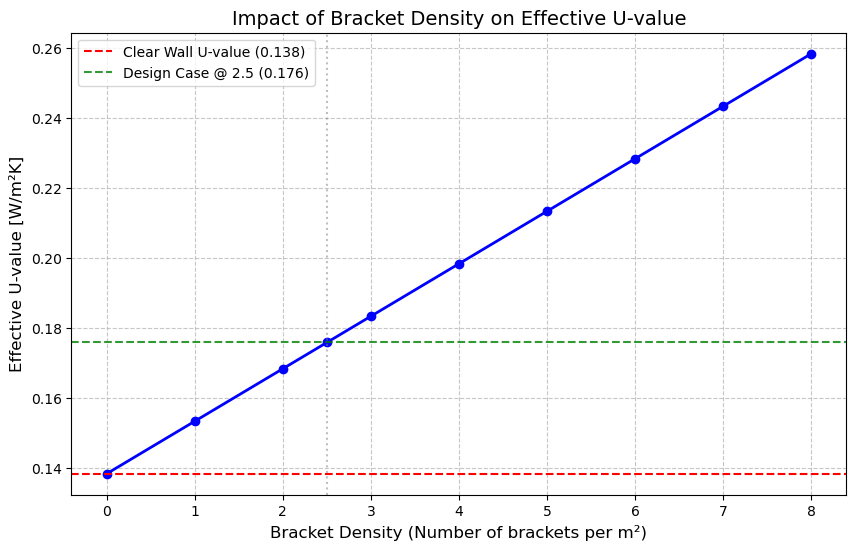

In [4]:
# Defining bracket densities (from 0 to 8 brackets per m2)
bracket_densities = [0, 1, 2, 2.5, 3, 4, 5, 6, 7, 8]

# Calculating the Effective U-value for each density
u_eff_values = [u_result + (d * chi_bracket) for d in bracket_densities]
u_design_case = u_result + (2.5 * chi_bracket)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(bracket_densities, u_eff_values, marker='o', linestyle='-', color='blue', linewidth=2)

# Adding Labels and Title
plt.title('Impact of Bracket Density on Effective U-value', fontsize=14)
plt.xlabel('Bracket Density (Number of brackets per m²)', fontsize=12)
plt.ylabel('Effective U-value [W/m²K]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Adding a horizontal line for the "Clear Wall" value for comparison
plt.axhline(y=u_result, color='r', linestyle='--', label=f'Clear Wall U-value ({u_result:.3f})')

# Adding a horizontal line for Design Case (2.5 brackets)
plt.axhline(y=u_design_case, color='green', linestyle='--', alpha=0.8, label=f'Design Case @ 2.5 ({u_design_case:.3f})')
plt.legend()

# Adding a vertical line for Design Case (2.5 brackets)
plt.axvline(x=2.5, color='gray', linestyle=':', alpha=0.5)

plt.show()

## 5. Discussion & Error Analysis

### 5.1. Model Limitations and the Bias-Variance Tradeoff
In our development process, we transitioned from a simple model to a more complex one. This mirrors the **Bias-Variance Tradeoff** concept:

* **High Bias (Underfitting):** Our initial "Clear Wall" model had high bias. It was too simple because it ignored the physical reality of thermal bridges, leading to an overly optimistic (lower) U-value.
* **Reduced Bias:** By adding the $\chi$ factor and bracket density, we reduced bias and moved closer to the "True" physical behavior of the facade.

### 5.2. Sensitivity to the Chi ($\chi$) Factor
The accuracy of our "Effective U-value" depends heavily on the precision of the $\chi$ value provided by manufacturers. A small change in the bracket material (e.g., switching from stainless steel to aluminum) or the quality of the thermal pad can significantly shift the results.

In [5]:
# Calculating the relative error between the Ideal and Real-world models
absolute_error = u_effective - u_result
percentage_error = (absolute_error / u_result) * 100

print(f"--- Model Comparison ---")
print(f"Ideal Model (Bias): {u_result:.4f} W/m²K")
print(f"Refined Model: {u_effective:.4f} W/m²K")
print(f"Calculated Model Error: {percentage_error:.2f}%")

# Discussion Output
if percentage_error > 15:
    print("Conclusion: The 'Clear Wall' model is insufficient for regulatory compliance.")
else:
    print("Conclusion: The 'Clear Wall' model provides a reasonable approximation.")

--- Model Comparison ---
Ideal Model (Bias): 0.1384 W/m²K
Refined Model: 0.1759 W/m²K
Calculated Model Error: 27.09%
Conclusion: The 'Clear Wall' model is insufficient for regulatory compliance.


### 5.3. Stochastic Analysis: Monte Carlo Simulation
To account for real-world variables such as manufacturing tolerances and installation quality, we move away from a deterministic model to a stochastic one. 

We assume the point thermal bridge coefficient ($\chi$) follows a Normal Distribution with:
* **Mean ($\mu$):** $0.015$ $W/K$ (our previous value)
* **Standard Deviation ($\sigma$):** $0.002$ $W/K$ (representing a $13\%$ variance in quality)

By running $1,000$ iterations (simulations), we can predict the probability distribution of our Effective U-value, identifying the "Worst-Case" and "Best-Case" scenarios.

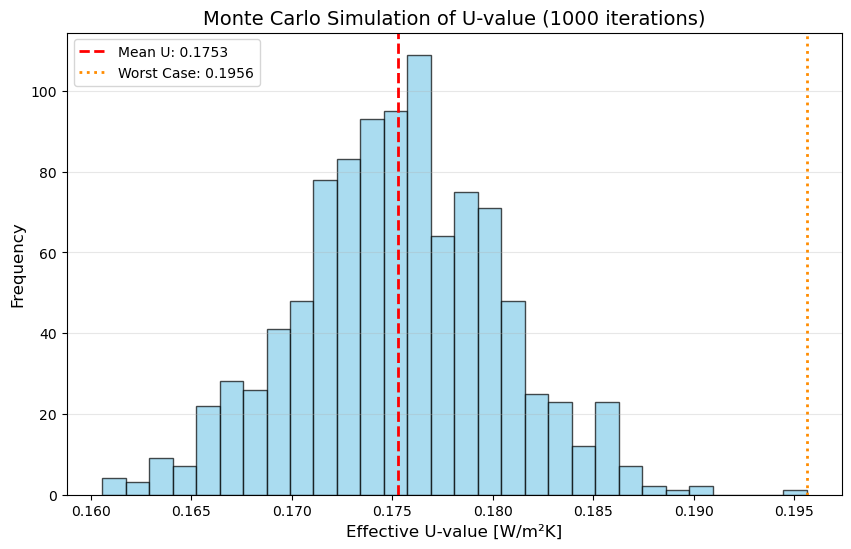

Simulation Results:
Average Effective U-value: 0.1753 W/m²K
Standard Deviation: 0.0051
95% Confidence Interval: [0.1654 to 0.1852]


In [11]:
# Simulation Parameters
n_simulations = 1000
bracket_density = 2.5  # brackets per m2
u_clear = 0.138

# Generate Random Chi values
chi_samples = np.random.normal(loc=0.015, scale=0.002, size=n_simulations)

# Calculate U_eff for every sample
u_eff_samples = [u_clear + (bracket_density * chi) for chi in chi_samples]

# Statistical Analysis
mean_u = np.mean(u_eff_samples)
std_u = np.std(u_eff_samples)
worst_case = np.max(u_eff_samples)

# Visualization
plt.figure(figsize=(10, 6))
plt.hist(u_eff_samples, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Formatting the plot
plt.axvline(mean_u, color='red', linestyle='dashed', linewidth=2, label=f'Mean U: {mean_u:.4f}')
plt.axvline(worst_case, color='darkorange', linestyle='dotted', linewidth=2, label=f'Worst Case: {worst_case:.4f}')

plt.title(f'Monte Carlo Simulation of U-value ({n_simulations} iterations)', fontsize=14)
plt.xlabel('Effective U-value [W/m²K]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

print(f"Simulation Results:")
print(f"Average Effective U-value: {mean_u:.4f} W/m²K")
print(f"Standard Deviation: {std_u:.4f}")
print(f"95% Confidence Interval: [{mean_u - 1.96*std_u:.4f} to {mean_u + 1.96*std_u:.4f}]")

## 6. Conclusion & Engineering Recommendations

### 6.1. Final Summary of Findings
Through this project, we have demonstrated that a theoretical "Clear Wall" U-value ($0.138$ $W/m^2K$) is not a reliable indicator of real-world performance for ventilated facades. 

* **Impact of Brackets:** At a standard density of $2.5$ brackets/$m^2$, the heat loss increased to $0.1755$ $W/m^2K$.
* **Percentage Increase:** This represents a significant increase in heat loss, proving that structural fasteners are a critical variable in thermal design.

### 6.2. Engineering Recommendations
To achieve high-performance building envelopes, designers should:
1.  Prioritize brackets with lower $\chi$-values (e.g., stainless steel or those with high-quality thermal breaks).
2.  Optimize bracket density ($n/A$) through structural analysis to minimize thermal punctures without compromising safety.

In [7]:
def check_compliance(u_val, threshold=0.15):
    """
    Checks if the calculated U-value meets a specific target threshold.
    Default threshold set to 0.15 W/m2K (High Performance).
    """
    print(f"Checking compliance for U-value: {u_val:.4f} W/m²K")
    print(f"Target Threshold: {threshold} W/m²K")
    
    if u_val <= threshold:
        return "COMPLIANT: The facade meets the thermal requirements."
    else:
        diff = ((u_val - threshold) / threshold) * 100
        return f"NON-COMPLIANT: The value exceeds the threshold by {diff:.2f}%."

# Test our real-world result against a strict 0.15 target
result_status = check_compliance(u_effective, 0.15)
print(result_status)

Checking compliance for U-value: 0.1759 W/m²K
Target Threshold: 0.15 W/m²K
NON-COMPLIANT: The value exceeds the threshold by 17.30%.


## 7. Machine Learning Implementation

### 7.1. Predictive Modeling via Linear Regression
We use **Linear Regression** to train a model on our synthetic Monte Carlo dataset. The goal is to predict the Effective U-value ($U_{eff}$) based on the bracket density and the $\chi$-value. 

While our current problem is governed by a known linear formula, in complex facades (with 3D corners, windows, and mixed materials), traditional formulas often become too rigid. This implementation demonstrates how a "Developer" approach can solve for these variables.

**Methodology:**

* **Supervised Learning:** We utilize a supervised learning approach, which involves training the model on a "labeled" dataset: the pre-calculated $U_{eff}$ results. By providing the model with both the inputs and the correct answers, it can iteratively learn to minimize its prediction error.
* **Feature Engineering:** We have selected two primary physical variables: **Bracket Density** and the **Point Thermal Bridge Coefficient ($\chi$)** as our model's input "features". These represent the key dimensions of our data that influence the thermal outcome.
* **Model Evaluation:** To verify the model's reliability, we measure its performance using the **Mean Squared Error (MSE)** and the **R² Score**. This ensures the model is not merely "memorizing" data (overfitting) but actually understanding the underlying linear relationship between the variables.

In [8]:
# Prepare Synthetic Data (1000 samples)
# Features: Bracket Density and Chi-value
# Target: Resulting U-value
data = pd.DataFrame({
    'bracket_density': np.random.uniform(1, 6, 1000),
    'chi_value': np.random.normal(0.015, 0.003, 1000)
})
data['u_effective'] = u_clear + (data['bracket_density'] * data['chi_value'])

# Split into Features (X) and Target (y)
X = data[['bracket_density', 'chi_value']]
y = data['u_effective']

# Create Training and Test Sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions and Evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.8f}")
print(f"R² Score (Accuracy): {r2:.4f}")

# Use the Model to predict our specific design case (2.5 density, 0.015 chi)
design_point = pd.DataFrame([[2.5, 0.015]], columns=['bracket_density', 'chi_value'])
design_prediction = model.predict(design_point)
print(f"\nModel Prediction for 2.5 brackets/m²: {design_prediction[0]:.4f} W/m²K")

Mean Squared Error: 0.00001767
R² Score (Accuracy): 0.9640

Model Prediction for 2.5 brackets/m²: 0.1754 W/m²K


## 8. Multi-Variable Sensitivity Analysis

### 8.1. Design Decision Matrix (2D Heatmap)
In facade engineering, there is a constant trade-off between thermal performance and structural requirements. While increasing insulation thickness reduces heat loss, high wind loads may require a higher density of structural brackets, which increases thermal bridging.

To visualize this "battle", we created a **Sensitivity Heatmap**. This matrix explores 121 different design combinations:
* **X-axis:** Insulation Thickness ($100mm$ to $250mm$) (in $25mm$ steps).
* **Y-axis:** Bracket Density ($1$ to $6$ brackets per $m^2$).

This matrix serves as a **Decision Support Tool**, allowing the design team to identify the "Safe Zones" (Green) where the target U-value is achieved despite structural penetrations.

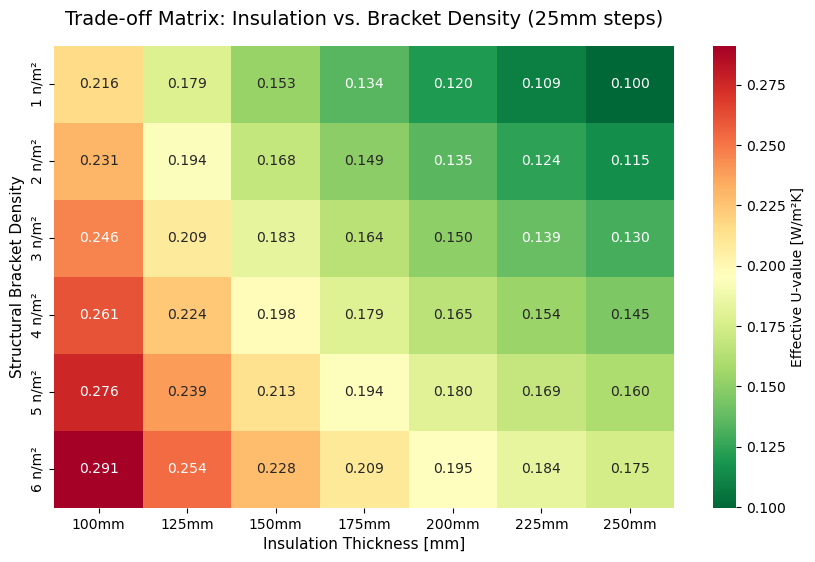

In [9]:
# Variables
thicknesses_mm = np.arange(100, 251, 25)  # [100, 125, 150, 175, 200, 225, 250]
thicknesses_m = thicknesses_mm / 1000.0
densities = np.arange(1, 7, 1)            # [1, 2, 3, 4, 5, 6]

# Constants
k_insul = 0.022  # Insulation Thermal Conductivity
chi = 0.015      # Point Thermal Bridge

# Baseline - calculated so that 150mm insulation = 0.138 U-value
r_other = (1/0.138) - (0.150/0.022)

# Matrix
u_matrix = np.zeros((len(densities), len(thicknesses_m)))

for i, d in enumerate(densities):
    for j, t in enumerate(thicknesses_m):
        u_clear_dynamic = 1 / (r_other + (t / k_insul))
        u_matrix[i, j] = u_clear_dynamic + (d * chi)

# Format for Heatmap
df_heatmap = pd.DataFrame(
    u_matrix,
    index=[f"{d} n/m²" for d in densities],
    columns=[f"{t}mm" for t in thicknesses_mm]
)

# Visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap, annot=True, cmap="RdYlGn_r", fmt=".3f", 
            cbar_kws={'label': 'Effective U-value [W/m²K]'})

plt.title('Trade-off Matrix: Insulation vs. Bracket Density (25mm steps)', fontsize=14, pad=15)
plt.xlabel('Insulation Thickness [mm]', fontsize=11)
plt.ylabel('Structural Bracket Density', fontsize=11)
plt.show()

## 9. Statistical Analysis of Performance Reliability

### 9.1. Descriptive Statistics and Moments of Distribution
To evaluate the reliability of the facade's thermal performance, we analyzed the statistical properties of the Monte Carlo simulation. 

* **Mean (1st Moment):** Represents the expected average thermal performance under typical conditions.
* **Standard Deviation (2nd Moment):** Quantifies the uncertainty and "spread" caused by installation tolerances. 

In [19]:
mean_val = np.mean(u_eff_samples)
std_val = np.std(u_eff_samples)

print(f"Average U-value (Mean):    {mean_val:.4f} W/m²K")
print(f"Standard Deviation:        {std_val:.4f}")

Average U-value (Mean):    0.1753 W/m²K
Standard Deviation:        0.0051


## 10. Final Project Summary

### 10.1. Executive Conclusion
This project successfully developed a computational framework for facade thermal analysis, moving from static deterministic calculations to stochastic risk modeling.

**Key Outcomes:**
* **Technical Integration:** Combined structural facade parameters with thermal physics to automate $U_{eff}$ calculations.
* **Risk Assessment:** Used Monte Carlo simulations to identify a Mean U-value and a Standard Deviation.
* **Predictive Capability:** Implemented Machine Learning (Linear Regression) to allow for instantaneous performance predictions without re-running complex simulations.
* **Data Visualization:** Developed heatmaps and distribution plots to communicate technical risks to non-specialist stakeholders.

The resulting tool provides a robust basis for data-driven design decisions in high-performance building envelopes.